**Chương 14 – Thị giác Máy tính Chuyên sâu Sử dụng Mạng Nơ-ron Tích chập**

_Notebook này chứa tất cả mã mẫu và lời giải cho các bài tập trong chương 14._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/14_deep_computer_vision_with_cnns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/14_deep_computer_vision_with_cnns.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Thiết lập

Dự án này yêu cầu Python 3.7 trở lên:

In [1]:
import sys

assert sys.version_info >= (3, 7)

Nó cũng yêu cầu Scikit-Learn $\ge$ 1.0.1:

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Và TensorFlow $\ge$ 2.8:

In [3]:
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

Như chúng ta đã làm trong các chương trước, hãy định nghĩa kích thước font mặc định để làm cho các hình ảnh đẹp hơn:

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Chương này có thể rất chậm nếu không có **GPU** (Bộ xử lý Đồ họa), vì vậy hãy đảm bảo rằng có một GPU, hoặc nếu không sẽ đưa ra cảnh báo:

In [5]:
# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

# Các Lớp Tích chập
## Triển khai Các Lớp Tích chập Bằng Keras

Hãy tải hai ảnh mẫu, thay đổi tỷ lệ giá trị pixel của chúng về 0-1, và cắt chính giữa (center crop) chúng thành các ảnh nhỏ 70x120:

In [6]:
from sklearn.datasets import load_sample_images
import tensorflow as tf

images = load_sample_images()["images"]
images = tf.keras.layers.CenterCrop(height=70, width=120)(images)
images = tf.keras.layers.Rescaling(scale=1 / 255)(images)

In [7]:
images.shape

TensorShape([2, 70, 120, 3])

In [8]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7)
fmaps = conv_layer(images)

In [9]:
fmaps.shape

TensorShape([2, 64, 114, 32])

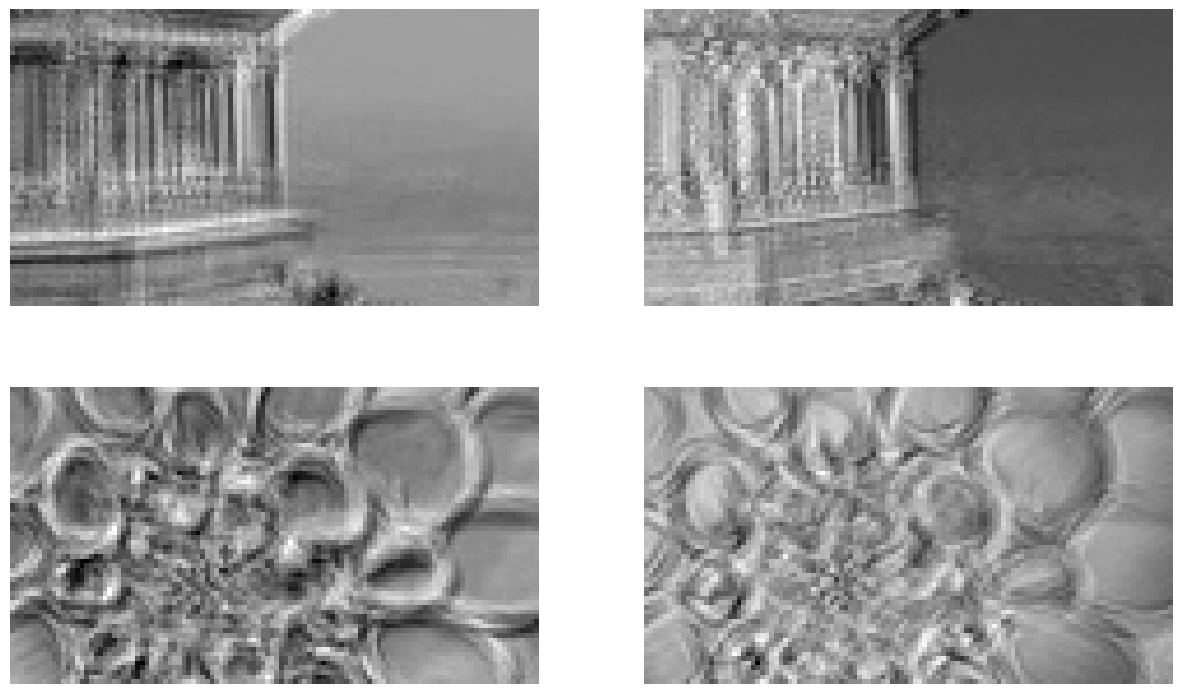

In [10]:
# extra code – displays the two output feature maps for each image

plt.figure(figsize=(15, 9))
for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, :, :, fmap_idx], cmap="gray")
        plt.axis("off")

plt.show()

Như bạn có thể thấy, các **bộ lọc được tạo ngẫu nhiên** (randomly generated filters) thường hoạt động như các **bộ phát hiện cạnh** (edge detectors), điều này rất tốt vì đó là một công cụ hữu ích trong xử lý ảnh, và đó là loại bộ lọc mà một lớp tích chập thường bắt đầu. Sau đó, trong quá trình huấn luyện, nó dần dần học được các bộ lọc được cải tiến để nhận dạng các mẫu hữu ích cho nhiệm vụ.

Bây giờ chúng ta hãy sử dụng **zero-padding** (đệm số 0):

In [11]:
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7,
                                    padding="same")
fmaps = conv_layer(images)

In [12]:
fmaps.shape

TensorShape([2, 70, 120, 32])

In [13]:
# extra code – shows that the output shape when we set strides=2
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7, padding="same",
                                    strides=2)
fmaps = conv_layer(images)
fmaps.shape

TensorShape([2, 35, 60, 32])

In [14]:
# extra code – this utility function can be useful to compute the size of the
#              feature maps output by a convolutional layer. It also returns
#              the number of ignored rows or columns if padding="valid", or the
#              number of zero-padded rows or columns if padding="same"."""

import numpy as np

def conv_output_size(input_size, kernel_size, strides=1, padding="valid"):
    if padding=="valid":
        z = input_size - kernel_size + strides
        output_size = z // strides
        num_ignored = z % strides
        return output_size, num_ignored
    else:
        output_size = (input_size - 1) // strides + 1
        num_padded = (output_size - 1) * strides + kernel_size - input_size
        return output_size, num_padded

conv_output_size(np.array([70, 120]), kernel_size=7, strides=2, padding="same")

(array([35, 60]), array([5, 5]))

Bây giờ chúng ta hãy xem xét các **trọng số** (weights):

In [15]:
kernels, biases = conv_layer.get_weights()
kernels.shape

(7, 7, 3, 32)

In [16]:
biases.shape

(32,)

In [17]:
# extra code – shows how to use the tf.nn.conv2d() operation

tf.random.set_seed(42)
filters = tf.random.normal([7, 7, 3, 2])
biases = tf.zeros([2])
fmaps = tf.nn.conv2d(images, filters, strides=1, padding="SAME") + biases

Bây giờ chúng ta hãy **tự tạo thủ công** (manually create) hai bộ lọc đầy số không (zeros), ngoại trừ một đường thẳng đứng gồm các số 1 trong bộ lọc thứ nhất, và một đường thẳng nằm ngang trong bộ lọc thứ hai (giống như trong Hình 14–5). Hai bản đồ đặc trưng đầu ra (output feature maps) lần lượt làm nổi bật các **đường thẳng đứng** và **đường thẳng nằm ngang**. Trên thực tế, bạn có lẽ sẽ không bao giờ cần phải tạo bộ lọc thủ công, vì các lớp tích chập sẽ tự động học chúng.

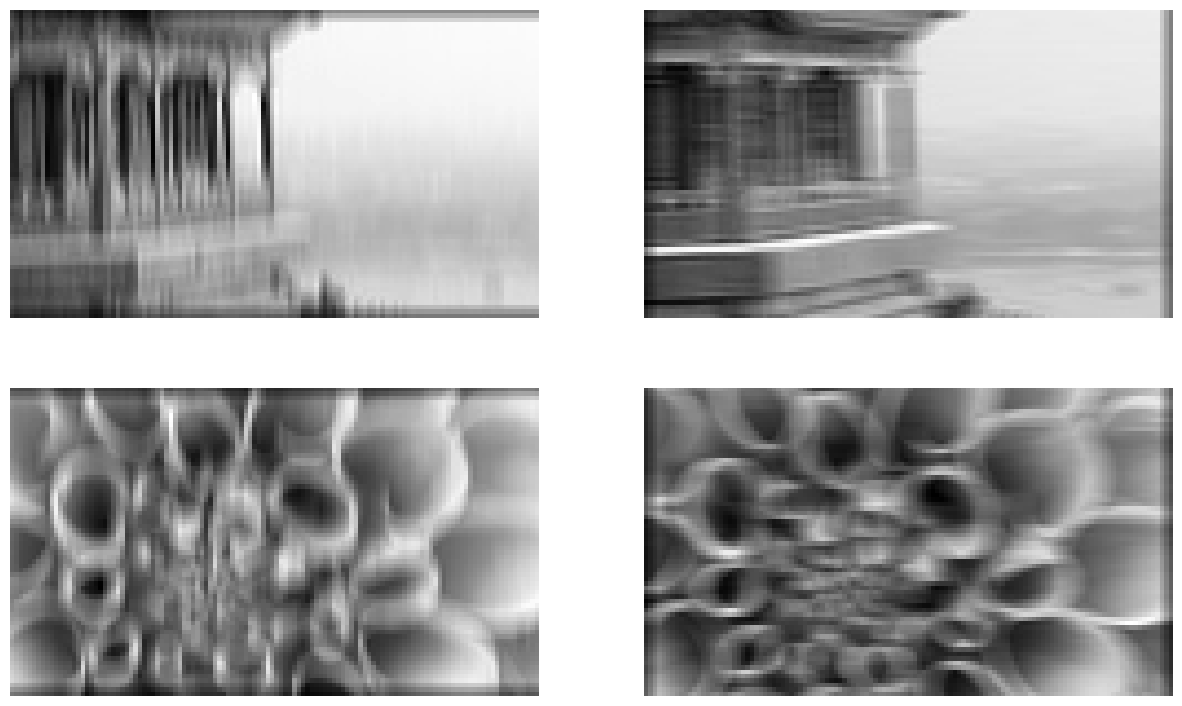

In [18]:
# extra code – shows how to manually create two filters to get images similar
#              to those in Figure 14–5.

plt.figure(figsize=(15, 9))
filters = np.zeros([7, 7, 3, 2])
filters[:, 3, :, 0] = 1
filters[3, :, :, 1] = 1
fmaps = tf.nn.conv2d(images, filters, strides=1, padding="SAME") + biases

for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, :, :, fmap_idx], cmap="gray")
        plt.axis("off")

plt.show()

Bạn có nhận thấy các đường tối màu ở phía trên và dưới của hai hình ảnh bên trái, và ở phía trái và phải của hai hình ảnh bên phải không? Bạn có thể đoán chúng là gì không? Tại sao chúng lại không xuất hiện trong hình trước?

Bạn đoán đúng rồi! Đây là các **hiện vật** (artifacts) do thực tế là chúng ta đã sử dụng **zero padding** (đệm số 0) trong trường hợp này, trong khi chúng ta không sử dụng zero padding để tạo các bản đồ đặc trưng (feature maps) trong hình trước. Vì **zero padding**, hai bản đồ đặc trưng dựa trên bộ lọc đường thẳng đứng (tức là hai hình ảnh bên trái) không thể được kích hoạt hoàn toàn gần phía trên và dưới của hình ảnh. Tương tự, hai bản đồ đặc trưng dựa trên bộ lọc đường thẳng nằm ngang (tức là hai hình ảnh bên phải) không thể được kích hoạt hoàn toàn gần phía trái và phải của hình ảnh.

# Các Lớp Gộp (Pooling Layers)
## Triển khai Các Lớp Gộp Bằng Keras

**Gộp Cực đại** (Max pooling)

In [19]:
max_pool = tf.keras.layers.MaxPool2D(pool_size=2)

In [20]:
output = max_pool(images)

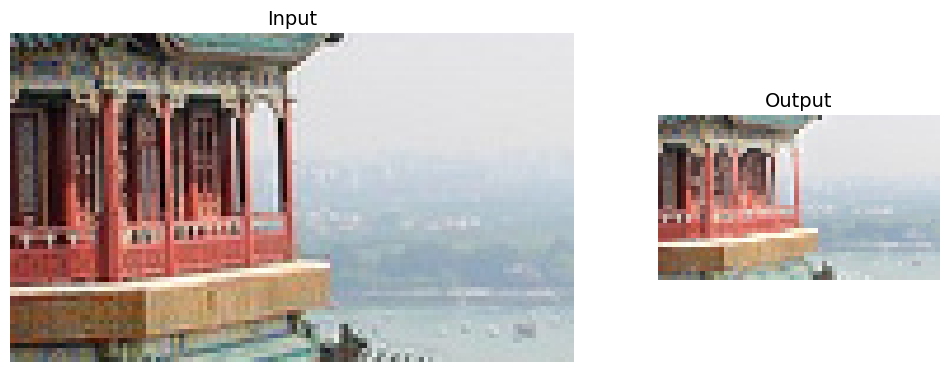

In [21]:
# extra code – this cells shows what max pooling with stride = 2 looks like

import matplotlib as mpl

fig = plt.figure(figsize=(12, 8))
gs = mpl.gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Input")
ax1.imshow(images[0])  # plot the 1st image
ax1.axis("off")
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("Output")
ax2.imshow(output[0])  # plot the output for the 1st image
ax2.axis("off")
plt.show()

**Gộp theo Chiều sâu** (Depth-wise pooling)

In [22]:
# extra code – shows how to use the max_pool() op; only works on the CPU
np.random.seed(42)
fmaps = np.random.rand(2, 70, 120, 60)
with tf.device("/cpu:0"):
    output = tf.nn.max_pool(fmaps, ksize=(1, 1, 1, 3), strides=(1, 1, 1, 3),
                            padding="VALID")
output.shape

TensorShape([2, 70, 120, 20])

In [23]:
class DepthPool(tf.keras.layers.Layer):
    def __init__(self, pool_size=2, **kwargs):
        super().__init__(**kwargs)
        self.pool_size = pool_size

    def call(self, inputs):
        shape = tf.shape(inputs)  # shape[-1] is the number of channels
        groups = shape[-1] // self.pool_size  # number of channel groups
        new_shape = tf.concat([shape[:-1], [groups, self.pool_size]], axis=0)
        return tf.reduce_max(tf.reshape(inputs, new_shape), axis=-1)

In [24]:
# extra code – shows that this custom layer gives the same result as max_pool()
np.allclose(DepthPool(pool_size=3)(fmaps), output)

True

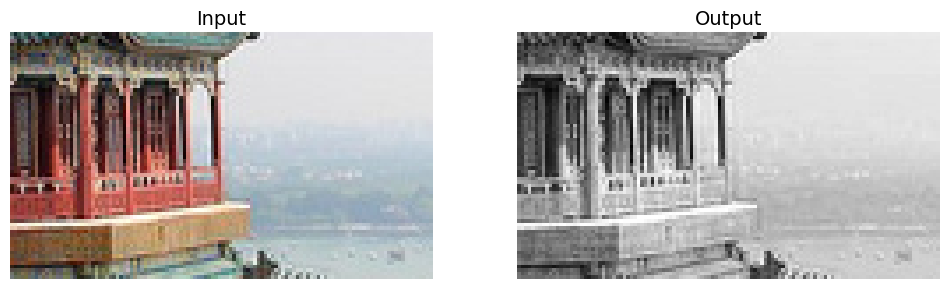

In [25]:
# extra code – computes and displays the output of the depthwise pooling layer

depth_output = DepthPool(pool_size=3)(images)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.title("Input")
plt.imshow(images[0])  # plot the 1st image
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("Output")
plt.imshow(depth_output[0, ..., 0], cmap="gray")  # plot 1st image's output
plt.axis("off")
plt.show()

**Gộp Trung bình Toàn cục** (Global Average Pooling)

In [26]:
global_avg_pool = tf.keras.layers.GlobalAvgPool2D()

Lớp sau đây là **tương đương**:

In [27]:
global_avg_pool = tf.keras.layers.Lambda(
    lambda X: tf.reduce_mean(X, axis=[1, 2]))

In [28]:
global_avg_pool(images)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0.643388  , 0.59718215, 0.5825038 ],
       [0.7630747 , 0.26010972, 0.10848834]], dtype=float32)>

# Các Kiến trúc CNN

**Giải quyết Fashion MNIST Bằng một CNN**

In [29]:
# extra code – loads the mnist dataset, add the channels axis to the inputs,
#              scales the values to the 0-1 range, and splits the dataset
mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = mnist
X_train_full = np.expand_dims(X_train_full, axis=-1).astype(np.float32) / 255
X_test = np.expand_dims(X_test.astype(np.float32), axis=-1) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [30]:
from functools import partial

tf.random.set_seed(42)  # extra code – ensures reproducibility
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, padding="same",
                        activation="relu", kernel_initializer="he_normal")
model = tf.keras.Sequential([
    DefaultConv2D(filters=64, kernel_size=7, input_shape=[28, 28, 1]),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=256),
    DefaultConv2D(filters=256),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=64, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
# extra code – compiles, fits, evaluates, and uses the model to make predictions
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))
score = model.evaluate(X_test, y_test)
X_new = X_test[:10]  # pretend we have new images
y_pred = model.predict(X_new)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.5630 - loss: 1.2104 - val_accuracy: 0.8608 - val_loss: 0.3954
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8350 - loss: 0.4803 - val_accuracy: 0.8896 - val_loss: 0.3158
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8714 - loss: 0.3894 - val_accuracy: 0.8924 - val_loss: 0.2994
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8847 - loss: 0.3401 - val_accuracy: 0.9056 - val_loss: 0.2772
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8977 - loss: 0.3053 - val_accuracy: 0.9036 - val_loss: 0.2770
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9069 - loss: 0.2789 - val_accuracy: 0.9042 - val_loss: 0.2834
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9116 - loss: 0.2637 - val_accuracy: 0.8972 - val_loss: 0.3062
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9162 - loss: 

## LeNet-5

Kiến trúc LeNet-5 nổi tiếng có các lớp sau:

Lớp   | Loại              | Maps | Kích thước | Kích thước Kernel | Stride | Hàm kích hoạt
-------|-----------------|------|----------|-------------|--------|-----------
 Out   | Kết nối đầy đủ  | –    | 10       | –           | –      | RBF
 F6    | Kết nối đầy đủ  | –    | 84       | –           | –      | tanh
 C5    | Tích chập       | 120  | 1 × 1    | 5 × 5       | 1      | tanh
 S4    | Gộp TB          | 16   | 5 × 5    | 2 × 2       | 2      | tanh
 C3    | Tích chập       | 16   | 10 × 10  | 5 × 5       | 1      | tanh
 S2    | Gộp TB          | 6    | 14 × 14  | 2 × 2       | 2      | tanh
 C1    | Tích chập       | 6    | 28 × 28  | 5 × 5       | 1      | tanh
 In    | Đầu vào         | 1    | 32 × 32  | –           | –      | –

Có một vài điều chỉnh ở đây và đó, mà hiện tại không còn quá quan trọng, nhưng trong trường hợp bạn quan tâm, đây là chúng:

* **Ảnh MNIST** có kích thước 28 × 28 pixel, nhưng chúng được **đệm số 0** (zero-padded) thành 32 × 32 pixel và được chuẩn hóa trước khi đưa vào mạng. Phần còn lại của mạng không sử dụng bất kỳ **đệm** (padding) nào, đó là lý do tại sao kích thước tiếp tục thu hẹp khi ảnh đi qua mạng.
* Các lớp **gộp trung bình** (average pooling layers) phức tạp hơn một chút so với thông thường: mỗi nơ-ron tính toán **giá trị trung bình** của các đầu vào của nó, sau đó nhân kết quả với một **hệ số có thể học** (learnable coefficient) (một hệ số cho mỗi bản đồ) và cộng thêm một **số hạng thiên vị có thể học** (learnable bias term) (cũng một số hạng cho mỗi bản đồ), rồi cuối cùng áp dụng hàm kích hoạt.
* Hầu hết các nơ-ron trong bản đồ C3 chỉ được kết nối với các nơ-ron trong ba hoặc bốn bản đồ S2 (thay vì tất cả sáu bản đồ S2). Xem bảng 1 (trang 8) trong [bài báo gốc](https://homl.info/lenet5) để biết chi tiết.
* Lớp đầu ra hơi đặc biệt: thay vì tính toán phép nhân ma trận của đầu vào và vector trọng số, mỗi nơ-ron xuất ra **bình phương khoảng cách Euclide** (square of the Euclidian distance) giữa vector đầu vào và vector trọng số của nó. Mỗi đầu ra đo lường mức độ hình ảnh thuộc về một lớp chữ số cụ thể. Hàm chi phí **cross-entropy** (entropy chéo) hiện được ưu tiên hơn, vì nó phạt các dự đoán sai nhiều hơn, tạo ra **độ dốc (gradients) lớn hơn** và hội tụ nhanh hơn.

# Triển khai một CNN ResNet-34 Bằng Keras

In [32]:
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, strides=1,
                        padding="same", kernel_initializer="he_normal",
                        use_bias=False)

class ResidualUnit(tf.keras.layers.Layer):
    def __init__(self, filters, strides=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)
        self.main_layers = [
            DefaultConv2D(filters, strides=strides),
            tf.keras.layers.BatchNormalization(),
            self.activation,
            DefaultConv2D(filters),
            tf.keras.layers.BatchNormalization()
        ]
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                tf.keras.layers.BatchNormalization()
            ]

    def call(self, inputs):
        Z = inputs
        for layer in self.main_layers:
            Z = layer(Z)
        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)
        return self.activation(Z + skip_Z)

In [33]:
model = tf.keras.Sequential([
    DefaultConv2D(64, kernel_size=7, strides=2, input_shape=[224, 224, 3]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same"),
])
prev_filters = 64
for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
    strides = 1 if filters == prev_filters else 2
    model.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters

model.add(tf.keras.layers.GlobalAvgPool2D())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(10, activation="softmax"))

# Sử dụng các Mô hình Đã Huấn luyện Sẵn từ Keras

In [34]:
model = tf.keras.applications.ResNet50(weights="imagenet")

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [35]:
images = load_sample_images()["images"]
images_resized = tf.keras.layers.Resizing(height=224, width=224,
                                          crop_to_aspect_ratio=True)(images)

In [36]:
inputs = tf.keras.applications.resnet50.preprocess_input(images_resized)

In [37]:
Y_proba = model.predict(inputs)
Y_proba.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


(2, 1000)

In [38]:
top_K = tf.keras.applications.resnet50.decode_predictions(Y_proba, top=3)
for image_index in range(len(images)):
    print(f"Image #{image_index}")
    for class_id, name, y_proba in top_K[image_index]:
        print(f"  {class_id} - {name:12s} {y_proba:.2%}")

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Image #0
  n03598930 - jigsaw_puzzle 30.68%
  n02782093 - balloon      17.17%
  n03888257 - parachute    5.57%
Image #1
  n04209133 - shower_cap   34.37%
  n09229709 - bubble       11.41%
  n02782093 - balloon      9.46%


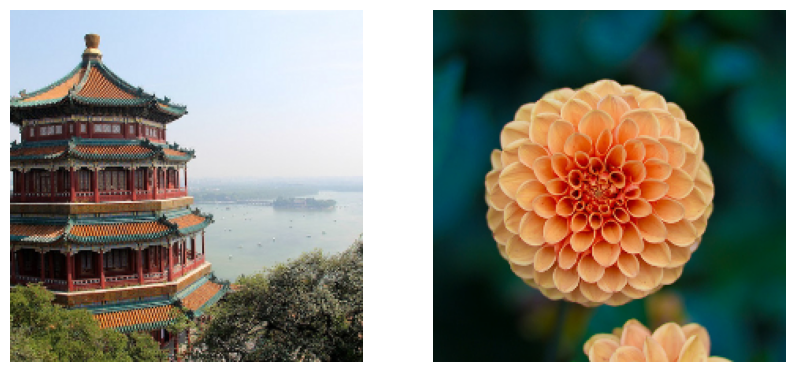

In [39]:
# extra code – displays the cropped and resized images

plt.figure(figsize=(10, 6))
for idx in (0, 1):
    plt.subplot(1, 2, idx + 1)
    plt.imshow(images_resized[idx] / 255)
    plt.axis("off")

plt.show()

# Các Mô hình Đã Huấn luyện Sẵn cho Học Chuyển giao

In [40]:
import tensorflow_datasets as tfds

dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
dataset_size = info.splits["train"].num_examples
class_names = info.features["label"].names
n_classes = info.features["label"].num_classes

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.AC77V2_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [41]:
dataset_size

3670

In [42]:
class_names

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

In [43]:
n_classes

5

In [44]:
test_set_raw, valid_set_raw, train_set_raw = tfds.load(
    "tf_flowers",
    split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
    as_supervised=True)

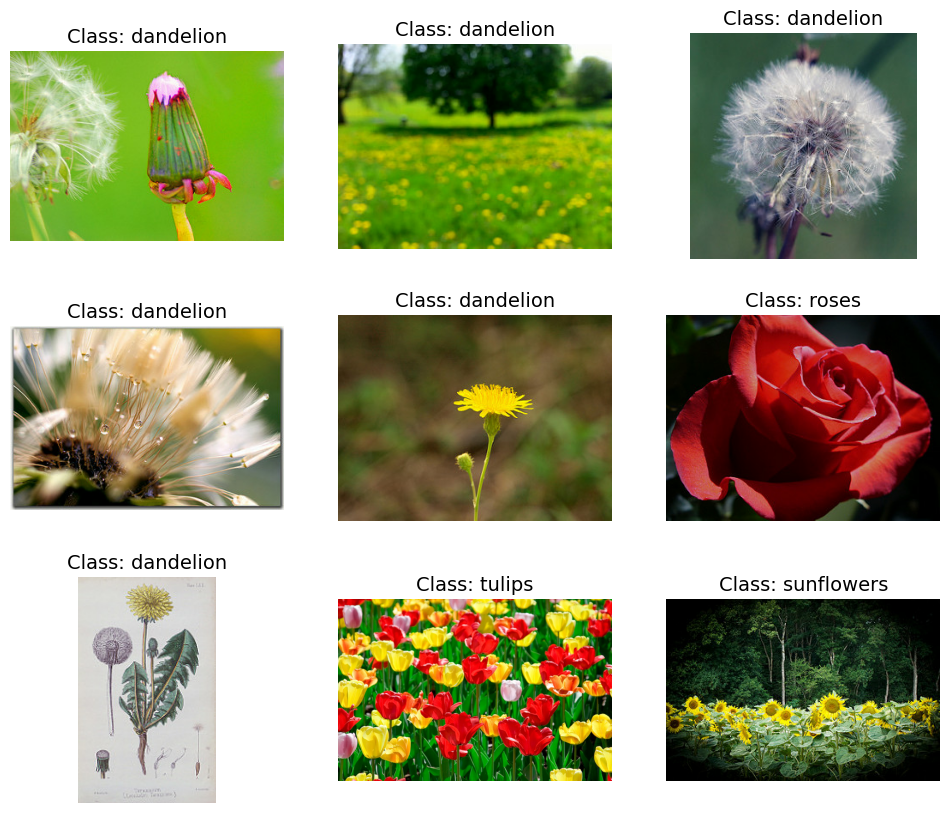

In [45]:
# extra code – displays the first 9 images in the validation set

plt.figure(figsize=(12, 10))
index = 0
for image, label in valid_set_raw.take(9):
    index += 1
    plt.subplot(3, 3, index)
    plt.imshow(image)
    plt.title(f"Class: {class_names[label]}")
    plt.axis("off")

plt.show()

Cả ba tập dữ liệu đều chứa các ảnh riêng lẻ. Chúng ta cần **tạo lô** (batch) cho chúng, nhưng trước tiên chúng ta cần đảm bảo rằng tất cả chúng đều có cùng kích thước, nếu không việc tạo lô sẽ không hoạt động. Chúng ta có thể sử dụng lớp **`Resizing`** (Thay đổi Kích thước) cho việc này. Chúng ta cũng phải gọi hàm **`tf.keras.applications.xception.preprocess_input()`** để tiền xử lý các ảnh một cách thích hợp cho mô hình Xception. Chúng ta cũng sẽ thêm **xáo trộn** (shuffling) và **tìm nạp trước** (prefetching) cho tập dữ liệu huấn luyện.

In [46]:
tf.keras.backend.clear_session()  # extra code – resets layer name counter

batch_size = 32
preprocess = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.xception.preprocess_input)
])
train_set = train_set_raw.map(lambda X, y: (preprocess(X), y))
train_set = train_set.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)
test_set = test_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)

Hãy cùng xem lại 9 hình ảnh đầu tiên từ **tập hợp xác thực** (validation set): tất cả chúng hiện đều có kích thước 224x224, với các giá trị nằm trong khoảng từ -1 đến 1:

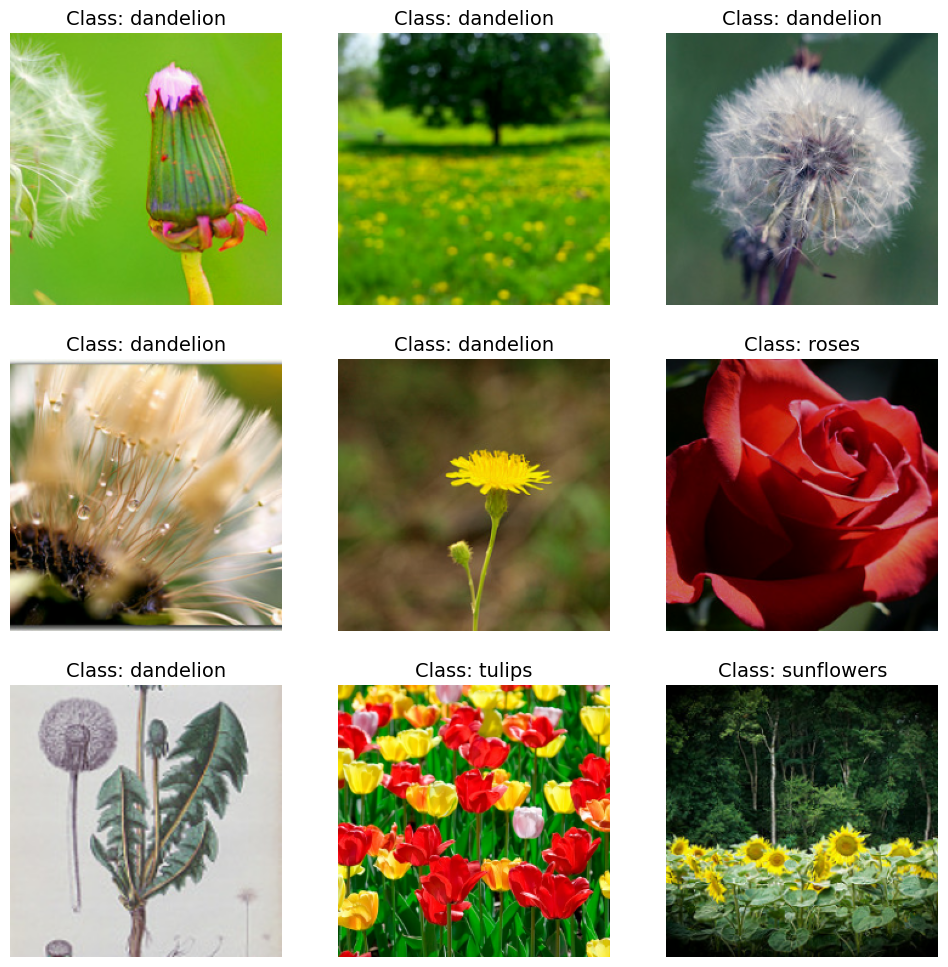

In [47]:
# extra code – displays the first 9 images in the first batch of valid_set

plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow((X_batch[index] + 1) / 2)  # rescale to 0–1 for imshow()
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()

In [48]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

Hãy thử chạy ô sau nhiều lần để xem các **tăng cường dữ liệu ngẫu nhiên** (random data augmentations) khác nhau:

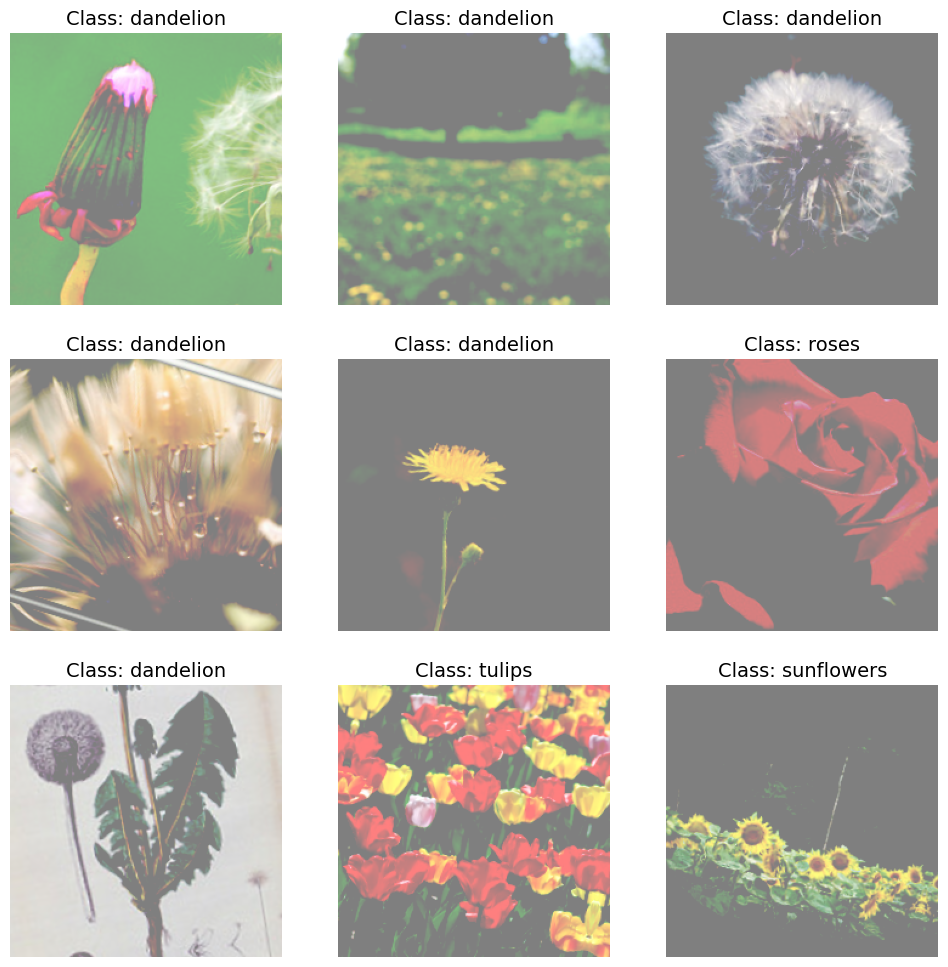

In [49]:
# extra code – displays the same first 9 images, after augmentation

plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    X_batch_augmented = data_augmentation(X_batch, training=True)
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        # We must rescale the images to the 0-1 range for imshow(), and also
        # clip the result to that range, because data augmentation may
        # make some values go out of bounds (e.g., RandomContrast in this case).
        plt.imshow(np.clip((X_batch_augmented[index] + 1) / 2, 0, 1))
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()

Bây giờ chúng ta hãy **tải mô hình đã huấn luyện sẵn** (pretrained model), **mà không có các lớp trên cùng** (top layers), và thay thế chúng bằng các lớp riêng của chúng ta, cho nhiệm vụ phân loại hoa:

In [50]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                     include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
model = tf.keras.Model(inputs=base_model.input, outputs=output)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [51]:
for layer in base_model.layers:
    layer.trainable = False

Bây giờ chúng ta hãy **huấn luyện mô hình** (train the model) trong vài **epochs** (kỷ nguyên), trong khi **giữ cố định các trọng số của mô hình cơ sở** (keeping the base model weights fixed):

In [52]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=3)

Epoch 1/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 52s 336ms/step - accuracy: 0.6893 - loss: 1.0368 - val_accuracy: 0.8530 - val_loss: 0.7330
Epoch 2/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 47s 150ms/step - accuracy: 0.9047 - loss: 0.4027 - val_accuracy: 0.8512 - val_loss: 0.6877
Epoch 3/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - accuracy: 0.9267 - loss: 0.2221 - val_accuracy: 0.8494 - val_loss: 0.7150


In [53]:
for indices in zip(range(33), range(33, 66), range(66, 99), range(99, 132)):
    for idx in indices:
        print(f"{idx:3}: {base_model.layers[idx].name:22}", end="")
    print()

  0: input_layer_2          33: block4_pool            66: block8_sepconv1_act    99: block11_sepconv2_act  
  1: block1_conv1           34: batch_normalization_2  67: block8_sepconv1       100: block11_sepconv2      
  2: block1_conv1_bn        35: add_2                  68: block8_sepconv1_bn    101: block11_sepconv2_bn   
  3: block1_conv1_act       36: block5_sepconv1_act    69: block8_sepconv2_act   102: block11_sepconv3_act  
  4: block1_conv2           37: block5_sepconv1        70: block8_sepconv2       103: block11_sepconv3      
  5: block1_conv2_bn        38: block5_sepconv1_bn     71: block8_sepconv2_bn    104: block11_sepconv3_bn   
  6: block1_conv2_act       39: block5_sepconv2_act    72: block8_sepconv3_act   105: add_9                 
  7: block2_sepconv1        40: block5_sepconv2        73: block8_sepconv3       106: block12_sepconv1_act  
  8: block2_sepconv1_bn     41: block5_sepconv2_bn     74: block8_sepconv3_bn    107: block12_sepconv1      
  9: block2_sepconv

Bây giờ các **trọng số** của các lớp trên cùng mới của chúng ta không còn quá tệ, chúng ta có thể **làm cho phần trên của mô hình cơ sở có thể huấn luyện lại** (make the top part of the base model trainable again), và tiếp tục huấn luyện, nhưng với **tốc độ học tập thấp hơn** (lower learning rate):

In [54]:
for layer in base_model.layers[56:]:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 55s 400ms/step - accuracy: 0.8692 - loss: 0.3926 - val_accuracy: 0.8475 - val_loss: 0.6612
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 27s 302ms/step - accuracy: 0.9782 - loss: 0.0778 - val_accuracy: 0.9111 - val_loss: 0.3759
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 27s 311ms/step - accuracy: 0.9945 - loss: 0.0180 - val_accuracy: 0.9165 - val_loss: 0.3387
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 28s 312ms/step - accuracy: 0.9992 - loss: 0.0058 - val_accuracy: 0.9220 - val_loss: 0.3101
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 28s 315ms/step - accuracy: 0.9985 - loss: 0.0055 - val_accuracy: 0.9238 - val_loss: 0.3114
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 28s 320ms/step - accuracy: 0.9993 - loss: 0.0023 - val_accuracy: 0.9256 - val_loss: 0.3013
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 28s 318ms/step - accuracy: 0.9983 - loss: 0.0042 - val_accuracy: 0.9292 - val_loss: 0.3254
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 28s 318ms/step - accuracy: 0.9993 - loss: 0.0027 - val_accu

# Phân loại và Định vị

**Lưu ý**: đoạn mã dưới đây đã từng tái sử dụng bộ **tối ưu hóa** (optimizer) từ mô hình trước đó. Điều này ổn trong các phiên bản TensorFlow cũ hơn, nhưng trong các phiên bản gần đây hơn, nó có thể gây ra một số vấn đề, vì vậy tôi đã thêm một dòng để tạo một bộ tối ưu hóa mới ở đây.

In [57]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                     include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
class_output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
loc_output = tf.keras.layers.Dense(4)(avg)
model = tf.keras.Model(inputs=base_model.input,
                       outputs=[class_output, loc_output])
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)  # added this line
# model.compile(loss=["sparse_categorical_crossentropy", "mse"],
#               loss_weights=[0.8, 0.2],  # depends on what you care most about
#               optimizer=optimizer, metrics=["accuracy"])
model.compile(
    loss=["sparse_categorical_crossentropy", "mse"],
    loss_weights=[0.8, 0.2],
    optimizer=optimizer,
    metrics=[["accuracy"], []]  # accuracy cho đầu ra 1, không metric cho đầu ra 2
)

In [58]:
# extra code – fits the model using random target bounding boxes (in real life
#              you would need to create proper targets instead)

def add_random_bounding_boxes(images, labels):
    fake_bboxes = tf.random.uniform([tf.shape(images)[0], 4])
    return images, (labels, fake_bboxes)

fake_train_set = train_set.take(5).repeat(2).map(add_random_bounding_boxes)
model.fit(fake_train_set, epochs=2)

Epoch 1/2
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 454ms/step - dense_3_accuracy: 0.3092 - dense_3_loss: 1.5734 - dense_4_loss: 0.3091 - loss: 1.3206
Epoch 2/2
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 504ms/step - dense_3_accuracy: 0.6114 - dense_3_loss: 1.1546 - dense_4_loss: 0.1850 - loss: 0.9607


# Tài liệu Bổ sung – mAP Liên quan đến Độ Chính xác/Độ Thu hồi như thế nào

In [59]:
def maximum_precisions(precisions):
    return np.flip(np.maximum.accumulate(np.flip(precisions)))

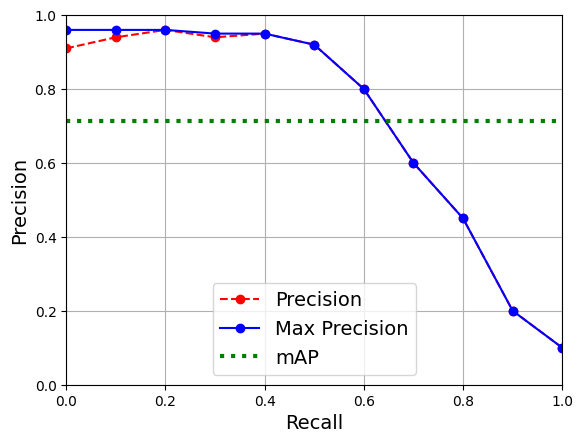

In [60]:
recalls = np.linspace(0, 1, 11)

precisions = [0.91, 0.94, 0.96, 0.94, 0.95, 0.92, 0.80, 0.60, 0.45, 0.20, 0.10]
max_precisions = maximum_precisions(precisions)
mAP = max_precisions.mean()
plt.plot(recalls, precisions, "ro--", label="Precision")
plt.plot(recalls, max_precisions, "bo-", label="Max Precision")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.plot([0, 1], [mAP, mAP], "g:", linewidth=3, label="mAP")
plt.grid(True)
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower center")
plt.show()

# Luyện tập

## 1. tới 8.

1. Đây là những **ưu điểm chính** của **Mạng Nơ-ron Tích chập (CNN)** so với **Mạng Nơ-ron Sâu Kết nối Đầy đủ (fully connected DNN)** đối với bài toán phân loại ảnh:
    * Vì các lớp liên tiếp chỉ được **kết nối một phần** (partially connected) và vì nó **tái sử dụng trọng số** (reuses its weights) rất nhiều, một CNN có số lượng tham số ít hơn nhiều so với một DNN kết nối đầy đủ, điều này giúp nó **huấn luyện nhanh hơn** rất nhiều, **giảm nguy cơ quá khớp** (overfitting), và yêu cầu ít dữ liệu huấn luyện hơn nhiều.
    * Khi một CNN đã học được một **kernel** (hạt nhân/bộ lọc) có thể phát hiện một **đặc trưng** (feature) cụ thể, nó có thể phát hiện đặc trưng đó ở **bất kỳ đâu** trong ảnh. Ngược lại, khi một DNN học được một đặc trưng tại một vị trí, nó chỉ có thể phát hiện đặc trưng đó tại đúng vị trí đó. Vì ảnh tự nhiên thường có các đặc trưng lặp đi lặp lại, CNN có khả năng **tổng quát hóa tốt hơn** nhiều so với DNN cho các nhiệm vụ xử lý ảnh như phân loại, chỉ cần ít ví dụ huấn luyện hơn.
    * Cuối cùng, một DNN **không có kiến thức tiên nghiệm** (no prior knowledge) về cách các pixel được tổ chức; nó không biết rằng các pixel gần nhau thì ở gần nhau. **Kiến trúc của CNN đã nhúng kiến thức tiên nghiệm này**. Các lớp thấp hơn thường nhận dạng các đặc trưng trong các vùng nhỏ của ảnh, trong khi các lớp cao hơn kết hợp các đặc trưng cấp thấp hơn thành các đặc trưng lớn hơn. Điều này hoạt động tốt với hầu hết các ảnh tự nhiên, mang lại cho CNN một lợi thế quyết định so với DNN.
---
2. Hãy tính toán xem CNN này có bao nhiêu tham số.
    * Vì lớp tích chập đầu tiên có **kernel 3 × 3**, và đầu vào có **ba kênh** (đỏ, lục và lam), mỗi bản đồ đặc trưng (feature map) có 3 × 3 × 3 trọng số, cộng với một **số hạng thiên vị** (bias term). Tổng cộng là 28 tham số cho mỗi bản đồ đặc trưng. Vì lớp tích chập đầu tiên này có 100 bản đồ đặc trưng, nó có tổng cộng 2.800 tham số. Lớp tích chập thứ hai có **kernel 3 × 3** và đầu vào của nó là tập hợp 100 bản đồ đặc trưng của lớp trước, nên mỗi bản đồ đặc trưng có 3 × 3 × 100 = 900 trọng số, cộng với một số hạng thiên vị. Vì nó có 200 bản đồ đặc trưng, lớp này có 901 × 200 = 180.200 tham số. Cuối cùng, lớp tích chập thứ ba và cuối cùng cũng có **kernel 3 × 3**, và đầu vào của nó là tập hợp 200 bản đồ đặc trưng của các lớp trước, nên mỗi bản đồ đặc trưng có 3 × 3 × 200 = 1.800 trọng số, cộng với một số hạng thiên vị. Vì nó có 400 bản đồ đặc trưng, lớp này có tổng cộng 1.801 × 400 = 720.400 tham số. Tổng cộng, CNN này có 2.800 + 180.200 + 720.400 = **903.400 tham số**.
    * Bây giờ hãy tính toán xem mạng nơ-ron này sẽ cần bao nhiêu **RAM** (ít nhất) khi đưa ra một dự đoán cho một **trường hợp duy nhất** (single instance). Đầu tiên, hãy tính kích thước bản đồ đặc trưng cho mỗi lớp. Vì chúng ta đang sử dụng **stride 2** và **`"same"` padding**, các chiều ngang và dọc của các bản đồ đặc trưng được chia cho 2 ở mỗi lớp (làm tròn lên nếu cần). Vì vậy, vì các kênh đầu vào là 200 × 300 pixel, các bản đồ đặc trưng của lớp đầu tiên là 100 × 150, các bản đồ đặc trưng của lớp thứ hai là 50 × 75, và các bản đồ đặc trưng của lớp thứ ba là 25 × 38. Vì **32 bit** là **4 byte** và lớp tích chập đầu tiên có 100 bản đồ đặc trưng, lớp đầu tiên này chiếm 4 × 100 × 150 × 100 = 6 triệu byte (6 MB). Lớp thứ hai chiếm 4 × 50 × 75 × 200 = 3 triệu byte (3 MB). Cuối cùng, lớp thứ ba chiếm 4 × 25 × 38 × 400 = 1.520.000 byte (khoảng 1.5 MB). Tuy nhiên, một khi một lớp đã được tính toán, bộ nhớ mà lớp trước đó chiếm có thể được **giải phóng** (released), vì vậy nếu mọi thứ được tối ưu hóa tốt, chỉ cần 6 + 3 = 9 triệu byte (9 MB) RAM là đủ (khi lớp thứ hai vừa được tính toán, nhưng bộ nhớ mà lớp đầu tiên chiếm chưa được giải phóng). Nhưng khoan đã, bạn cũng cần cộng thêm bộ nhớ mà các **tham số của CNN** chiếm! Chúng ta đã tính toán trước đó rằng nó có 903.400 tham số, mỗi tham số chiếm 4 byte, vì vậy điều này cộng thêm 3.613.600 byte (khoảng 3.6 MB). Do đó, tổng RAM yêu cầu (ít nhất) là 12.613.600 byte (khoảng **12.6 MB**).
    * Cuối cùng, hãy tính toán lượng RAM tối thiểu cần thiết khi **huấn luyện CNN** trên một **mini-batch 50 ảnh**. Trong quá trình huấn luyện, TensorFlow sử dụng **lan truyền ngược** (backpropagation), đòi hỏi phải giữ tất cả các giá trị được tính toán trong **lượt truyền xuôi** (forward pass) cho đến khi lượt truyền ngược (reverse pass) bắt đầu. Vì vậy, chúng ta phải tính tổng RAM cần thiết bởi tất cả các lớp cho một trường hợp duy nhất và nhân nó với 50. Tại thời điểm này, hãy bắt đầu tính bằng megabyte thay vì byte. Chúng ta đã tính trước đó rằng ba lớp lần lượt yêu cầu 6, 3 và 1.5 MB cho mỗi trường hợp. Tổng cộng là 10.5 MB cho mỗi trường hợp, vì vậy cho 50 trường hợp, tổng RAM cần thiết là 525 MB. Cộng thêm RAM cần thiết bởi các ảnh đầu vào, là 50 × 4 × 200 × 300 × 3 = 36 triệu byte (36 MB), cộng với RAM cần thiết cho các tham số mô hình, khoảng 3.6 MB (đã tính trước đó), cộng thêm một ít RAM cho các đạo hàm (gradients) (chúng ta sẽ bỏ qua điều này vì nó có thể được giải phóng dần dần khi lan truyền ngược đi xuống các lớp trong lượt truyền ngược). Tổng cộng chúng ta có khoảng 525 + 36 + 3.6 = **564.6 MB**, và đó thực sự là mức tối thiểu lạc quan nhất.
---
3. Nếu **GPU** của bạn hết bộ nhớ trong khi huấn luyện một CNN, đây là năm điều bạn có thể thử để giải quyết vấn đề (ngoài việc mua một GPU có nhiều RAM hơn):
    * **Giảm kích thước mini-batch** (Reduce the mini-batch size).
    * **Giảm số chiều** (Reduce dimensionality) bằng cách sử dụng **stride lớn hơn** trong một hoặc nhiều lớp.
    * **Loại bỏ** một hoặc nhiều lớp.
    * Sử dụng **số thực 16-bit** (16-bit floats) thay vì số thực 32-bit.
    * **Phân phối CNN** trên nhiều thiết bị.
---
4. Một **lớp gộp cực đại** (max pooling layer) **không có bất kỳ tham số** nào cả, trong khi một **lớp tích chập** (convolutional layer) có khá nhiều (xem các câu hỏi trước).
---
5. Một **lớp chuẩn hóa phản hồi cục bộ** (local response normalization layer) làm cho các nơ-ron được kích hoạt mạnh nhất **ức chế** (inhibit) các nơ-ron tại cùng một vị trí nhưng trong các bản đồ đặc trưng lân cận, điều này khuyến khích các bản đồ đặc trưng khác nhau **chuyên biệt hóa** (specialize) và đẩy chúng ra xa nhau, buộc chúng phải khám phá một phạm vi đặc trưng rộng hơn. Nó thường được sử dụng trong các lớp thấp hơn để có một tập hợp lớn hơn các đặc trưng cấp thấp mà các lớp trên có thể xây dựng dựa trên.
---
6. Các **đổi mới chính** trong **AlexNet** so với LeNet-5 là nó **lớn hơn và sâu hơn** nhiều, và nó **xếp chồng các lớp tích chập** trực tiếp lên nhau, thay vì xếp chồng một lớp gộp lên trên một lớp tích chập. Đổi mới chính trong **GoogLeNet** là sự ra đời của **_các mô-đun inception_** (inception modules), giúp có thể có một mạng sâu hơn nhiều so với các kiến trúc CNN trước đó, với **ít tham số hơn**. Đổi mới chính của **ResNet** là sự ra đời của **kết nối tắt** (skip connections), giúp có thể vượt xa 100 lớp. Có thể nói, sự đơn giản và tính nhất quán của nó cũng khá đổi mới. Đổi mới chính của **SENet** là ý tưởng sử dụng một **khối SE** (SE block - một mạng dày đặc hai lớp) sau mỗi mô-đun inception trong mạng inception hoặc mỗi đơn vị dư thừa (residual unit) trong ResNet để **hiệu chỉnh lại tầm quan trọng tương đối của các bản đồ đặc trưng** (recalibrate the relative importance of feature maps). Đổi mới chính của **Xception** là việc sử dụng **các lớp tích chập tách biệt chiều sâu** (depthwise separable convolutional layers), tách biệt việc xem xét các **mẫu không gian** (spatial patterns) và các **mẫu theo chiều sâu** (depthwise patterns). Cuối cùng, đổi mới chính của **EfficientNet** là **phương pháp điều chỉnh hợp chất** (compound scaling method), để mở rộng quy mô một mô hình một cách hiệu quả theo một ngân sách tính toán lớn hơn.
---
7. **Mạng tích chập đầy đủ (Fully Convolutional Networks - FCNs)** là các mạng nơ-ron được cấu tạo **độc quyền** từ các lớp tích chập và lớp gộp. FCN có thể xử lý hiệu quả các ảnh có bất kỳ chiều rộng và chiều cao nào (ít nhất là trên kích thước tối thiểu). Chúng hữu ích nhất cho **phát hiện đối tượng** (object detection) và **phân đoạn ngữ nghĩa** (semantic segmentation) vì chúng chỉ cần nhìn vào ảnh một lần (thay vì phải chạy một CNN nhiều lần trên các phần khác nhau của ảnh). Nếu bạn có một CNN với một số lớp dày đặc (dense layers) ở trên cùng, bạn có thể **chuyển đổi các lớp dày đặc này thành các lớp tích chập** để tạo ra một FCN: chỉ cần thay thế lớp dày đặc thấp nhất bằng một lớp tích chập với **kích thước kernel bằng với kích thước đầu vào của lớp đó**, với **một bộ lọc cho mỗi nơ-ron** trong lớp dày đặc, và sử dụng **`"valid"` padding**. Nói chung, **stride** nên là 1, nhưng bạn có thể đặt nó thành một giá trị cao hơn nếu muốn. **Hàm kích hoạt** phải giống như của lớp dày đặc. Các lớp dày đặc khác nên được chuyển đổi theo cùng một cách, nhưng sử dụng **bộ lọc 1 × 1**. Trên thực tế, có thể chuyển đổi một CNN đã được huấn luyện theo cách này bằng cách thay đổi hình dạng ma trận trọng số của các lớp dày đặc một cách thích hợp.
---
8. Khó khăn kỹ thuật chính của **phân đoạn ngữ nghĩa** (semantic segmentation) là thực tế là rất nhiều **thông tin không gian** (spatial information) bị mất trong một CNN khi tín hiệu truyền qua từng lớp, đặc biệt là trong **các lớp gộp** (pooling layers) và các lớp có **stride lớn hơn 1**. Thông tin không gian này cần phải được **khôi phục** bằng cách nào đó để dự đoán chính xác lớp của từng pixel.

## 9. CNN Độ Chính xác Cao cho MNIST
_Bài tập: Xây dựng CNN của riêng bạn từ đầu và cố gắng đạt được độ chính xác cao nhất có thể trên MNIST._

Mô hình sau sử dụng **2 lớp tích chập** (convolutional layers), tiếp theo là **1 lớp gộp** (pooling layer), sau đó là **dropout 25%**, rồi một **lớp dày đặc** (dense layer), một lớp **dropout** khác nhưng với **50% dropout**, và cuối cùng là **lớp đầu ra** (output layer). Nó đạt khoảng **99.2% độ chính xác** trên tập kiểm tra (test set). Điều này đặt mô hình này vào khoảng **top 20%** trong [cuộc thi MNIST Kaggle](https://www.kaggle.com/c/digit-recognizer/) (nếu chúng ta bỏ qua các mô hình có độ chính xác lớn hơn 99.79% mà rất có thể đã được huấn luyện trên tập kiểm tra, như giải thích bởi Chris Deotte trong [bài đăng này](https://www.kaggle.com/c/digit-recognizer/discussion/61480)). Bạn có thể làm tốt hơn không? Để đạt độ chính xác từ **99.5 đến 99.7%** trên tập kiểm tra, bạn cần thêm **tăng cường ảnh** (image augmentation), **batch norm** (chuẩn hóa lô), sử dụng **lịch trình học tập** (learning schedule) như **1-cycle**, và có thể tạo ra một **mô hình tổ hợp** (ensemble).

In [ ]:
mnist = tf.keras.datasets.mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = mnist
X_train_full = X_train_full / 255.
X_test = X_test / 255.
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, kernel_size=3, padding="same",
                           activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Conv2D(64, kernel_size=3, padding="same",
                           activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(128, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])

model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))
model.evaluate(X_test, y_test)

## 10. Sử dụng Học Chuyển giao cho Phân loại Ảnh Lớn

_Bài tập: Sử dụng **học chuyển giao** (transfer learning) để **phân loại ảnh lớn** (large image classification), đi qua các bước sau:_

* _Tạo một **tập huấn luyện** (training set) chứa ít nhất 100 ảnh cho mỗi lớp. Ví dụ, bạn có thể phân loại ảnh của riêng mình dựa trên vị trí (bãi biển, núi, thành phố, v.v.), hoặc thay vào đó bạn có thể sử dụng một **tập dữ liệu hiện có** (existing dataset) (ví dụ: từ TensorFlow Datasets)._
* _**Chia** nó thành một tập huấn luyện, một tập xác thực (validation set), và một tập kiểm tra (test set)._
* _Xây dựng **đường dẫn đầu vào** (input pipeline), bao gồm các thao tác **tiền xử lý** (preprocessing) thích hợp, và tùy chọn thêm **tăng cường dữ liệu** (data augmentation)._
* _**Tinh chỉnh** (fine-tune) một mô hình đã huấn luyện sẵn trên tập dữ liệu này._

Xem ví dụ về **Hoa** ở trên.

## 11.
_Bài tập: Hoàn thành [hướng dẫn Chuyển đổi Phong cách](https://homl.info/styletuto) (Style Transfer tutorial) của TensorFlow. Đây là một cách thú vị để tạo ra nghệ thuật bằng Học Sâu (Deep Learning)._

Chỉ cần mở **Colab** và làm theo các hướng dẫn của nó.